# Alpha-FX: Intelligent Forex Trading System

Welcome to **Alpha-FX**, a Deep Reinforcement Learning (DRL) system designed to trade foreign exchange markets.

## 🎯 Goal
The goal of this notebook is to walk you through the entire lifecycle of an algorithmic trading agent:
1.  **DataOps**: Ingesting and processing financial data (Prices, Indicators, Macro yields).
2.  **Training**: Teaching an AI agent (PPO) to trade profitably.
3.  **Evaluation**: Testing the agent against a "Buy & Hold" baseline to verify performance.

## 🌍 FX Context
We trade a portfolio of major currency pairs (`EURUSD`, `GBPUSD`, etc.) against the US Dollar.
*   **The Strategy**: The agent learns to allocate portfolio weights (e.g., 50% EUR, 50% USD) to maximize returns while managing risk (volatility).
*   **The Edge**: We provide the agent with **Macroeconomic Data** (US Treasury Yields) so it can understand interest rate trends (Carry Trade).

---

### 🔎 System Overview
The data flows from raw Yahoo Finance inputs to a trained model.

```mermaid
graph LR
    A[Yahoo Finance] -->|Fetch| B(Data Pipeline)
    B -->|Clean & Feature Eng| C[(Parquet Dataset)]
    C -->|Train| D[RL Agent (PPO)]
    D -->|Evaluate| E[Backtest & Benchmark]
```

## 1. Setup & Dependencies
First, we ensure all necessary libraries are installed and importable.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import gymnasium as gym
import stable_baselines3
import matplotlib.pyplot as plt
import torch

# Add root to path so we can import local modules
sys.path.append(os.path.abspath('.'))

print(f"Pandas: {pd.__version__}")
print(f"Gymnasium: {gym.__version__}")
print(f"Stable Baselines3: {stable_baselines3.__version__}")

# Check for GPU
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
    print("🚀 NVIDIA CUDA GPU Detected!")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
    print("🍎 Apple Metal GPU (MPS) Detected!")
else:
    print("💻 Running on CPU.")

Pandas: 2.3.3
Gymnasium: 1.2.2
Stable Baselines3: 2.7.1
🍎 Apple Metal GPU (MPS) Detected!


## 2. Data Operations (DataOps)

We need to fetch historical data for our currency pairs. We also fetch **Macro Data** (US 10-Year Treasury Yield `^TNX`) to help the agent understand the broader economic environment.

### Pipeline Steps:
1.  **Fetch**: Download OHLCV data from Yahoo Finance (2018-2023).
2.  **Clean**: Fix missing values (Market holidays).
3.  **Feature Engineering**: Add technical indicators:
    *   **Trend**: MACD, ADX.
    *   **Volatility**: ATR, Bollinger Bands.
    *   **Momentum**: RSI, Williams %R.
    *   **Macro**: US Risk-Free Rate (Yield).
4.  **Save**: Output to `data/fx_data_2018_2023.parquet`.

In [2]:
from planning.run_pipeline import main as run_pipeline

# Customize Data Scope
TICKERS = ['EURUSD=X', 'GBPUSD=X', 'JPY=X', 'SEK=X', 'EURSEK=X']
START_DATE = '2018-01-01'
END_DATE = '2023-01-01'

# Run the Data Pipeline
run_pipeline(tickers=TICKERS, start_date=START_DATE, end_date=END_DATE)

Fetching data from 2018-01-01 to 2023-01-01 for ['EURUSD=X', 'GBPUSD=X', 'JPY=X', 'SEK=X', 'EURSEK=X']...


/Users/mathias/Documents/local-dev/AI/FinRL/dataops/pipeline.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  5 of 5 completed
/Users/mathias/Documents/local-dev/AI/FinRL/planning/run_pipeline.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(level=1).reset_index().rename(columns={'level_1': 'tic', 'Ticker': 'tic'})
/Users/mathias/Documents/local-dev/AI/FinRL/dataops/pipeline.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date, interval=interval)


Raw shape: (1305, 25)
Detected MultiIndex columns, converting to long format...
Long format shape: (6521, 7)
Cleaning data...
Adding features...
Merging Macro Data (^TNX)...


[*********************100%***********************]  1 of 1 completed

Normalizing data...
Filtering non-square data. Dropping 3 dates.
Final shape: (6505, 22)
                 tic       close        high         low        open  volume  \
date                                                                           
2018-01-04  EURSEK=X    9.824410    9.830630    9.803730    9.824550     0.0   
2018-01-04     SEK=X    8.180600    8.183990    8.122800    8.179900     0.0   
2018-01-04  EURUSD=X    1.201043    1.209190    1.200495    1.201129     0.0   
2018-01-04  GBPUSD=X    1.351132    1.356116    1.350658    1.351169     0.0   
2018-01-04     JPY=X  112.607002  112.853996  112.507004  112.606003     0.0   

                macd     macds     macdh     rsi_30  ...        boll  \
date                                                 ...               
2018-01-04  0.000354  0.000341  0.000013  57.936172  ...    9.826535   
2018-01-04 -0.000158 -0.000249  0.000090  51.612819  ...    8.174213   
2018-01-04  0.000059  0.000072 -0.000013  51.515398  ...    1.

In [5]:
# Inspect the generated data
df = pd.read_parquet('data/fx_data_2018_2023.parquet')
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample Data:")
df.sample(5)

Dataset Shape: (6505, 22)
Columns: ['tic', 'close', 'high', 'low', 'open', 'volume', 'macd', 'macds', 'macdh', 'rsi_30', 'cci_30', 'dx_30', 'boll', 'boll_ub', 'boll_lb', 'atr', 'dx', 'adx', 'adxr', 'wr', 'us_roi', 'log_return']

Sample Data:


,tic,close,high,low,open,volume,macd,macds,macdh,rsi_30,...,boll,boll_ub,boll_lb,atr,dx,adx,adxr,wr,us_roi,log_return
date,,,,,,,,,,,,,,,,,,,,,
2021-07-13,JPY=X,110.324997,110.550003,110.202003,110.328003,0.0,0.157473,0.289369,-0.131896,53.339287,...,110.631299,111.472302,109.790296,0.634646,5.305695,12.777306,17.658232,-62.753639,1.415,0.000998
2020-09-21,EURUSD=X,1.184553,1.187300,1.173268,1.184553,0.0,0.002074,0.003036,-0.000962,57.377388,...,1.184355,1.192832,1.175878,0.009309,15.241633,10.241863,10.704134,-41.121629,0.671,-0.000225
2018-11-13,EURUSD=X,1.123343,1.129191,1.122322,1.122410,0.0,-0.005797,-0.005124,-0.000674,37.382327,...,1.141075,1.156444,1.125706,0.008395,28.558686,19.893063,18.294698,-96.309795,3.145,-0.008121
2022-05-17,EURUSD=X,1.043896,1.055376,1.043242,1.043896,0.0,-0.011600,-0.011184,-0.000416,35.469007,...,1.059030,1.087246,1.030815,0.010820,13.563241,30.346152,32.983142,-69.797655,2.968,0.003678
2020-05-07,JPY=X,106.191002,106.646004,106.139000,106.209999,0.0,-0.459581,-0.347604,-0.111977,43.899352,...,107.360500,108.621091,106.099909,0.847423,25.629587,26.765841,26.546793,-91.418300,0.631,-0.002455


## 3. Training the Agent

We use **PPO (Proximal Policy Optimization)**, a state-of-the-art reinforcement learning algorithm. 

You can now **Fine-Tune** the agent strategies using these parameters:
1.  **`total_timesteps`**: How long the agent practices. (Default: 30,000. Try 100k+ for real results).
2.  **`lookback`**: The window of historical data the agent sees. (Default: 10 days. Try 30 to capture monthly trends).
3.  **`ent_coef`**: Exploration rate. Higher values (e.g., 0.01) encourage trying new things; lower values stick to what works.
4.  **`device`**: 'auto', 'cuda' (Nvidia), 'mps' (Mac), or 'cpu'. Using GPU significantly speeds up training.

In [ ]:
from train_agent import train

LOOK_BACK = 20 # Window size

# Interactive Training Control
# Advanced: Increase lookback to 30 days and add some exploration
# Using the detected device from Step 1
train(
    total_timesteps=30000, 
    lookback=LOOK_BACK,    # Window size
    ent_coef=0.02,         # encourage exploration
    device='cpu'          # Use GPU if available
)

Output()

Stock Dim: 5, State Space: 1500, Lookback: 30
Training Agent for 30000 steps | LR=2.27e-05 | Ent Coef=0.01 | Lookback=30 | Device=cpu...


Training finished.
Model saved to models/fx_agent_tuned


### 📊 Training Visualization
Let's see how the agent learned over time. We plot the **Episode Reward** (smoothed).
*   **Upward Trend**: The agent is learning strategies that generate more return (or lose less).
*   **Flat/Down**: The agent is struggling or market conditions are too chaotic.

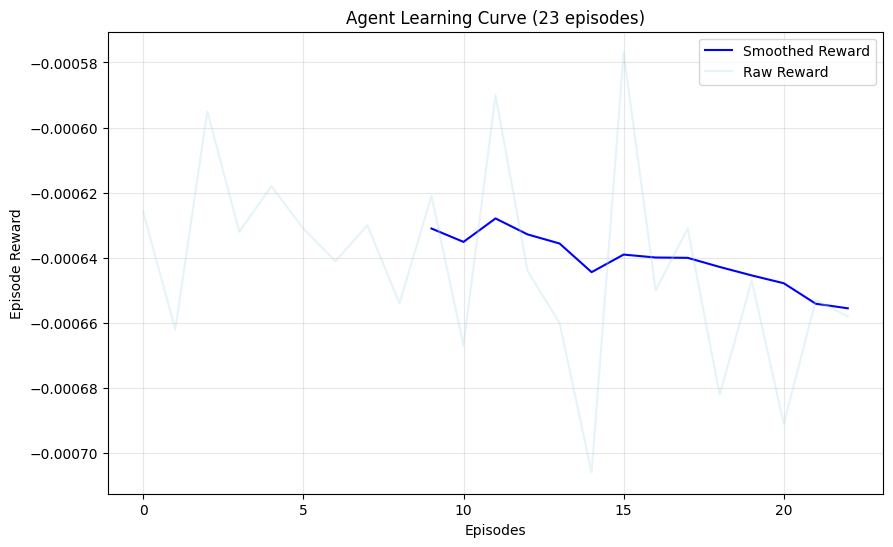

In [9]:
# Plot Learning Curve
try:
    # SB3 Monitor logs file format: first line is metadata, second line is header
    log_path = 'results/monitor.csv'
    if os.path.exists(log_path):
        log_df = pd.read_csv(log_path, skiprows=1)
        # Format: r (rewards), l (length), t (time)
        if 'r' in log_df.columns:
            # Smooth it for readability
            log_df['smoothed_reward'] = log_df['r'].rolling(window=10).mean()
            
            plt.figure(figsize=(10, 6))
            plt.plot(log_df.index, log_df['smoothed_reward'], label='Smoothed Reward', color='blue')
            plt.plot(log_df.index, log_df['r'], label='Raw Reward', color='lightblue', alpha=0.3)
            plt.title(f"Agent Learning Curve ({len(log_df)} episodes)")
            plt.xlabel("Episodes")
            plt.ylabel("Episode Reward")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("Log file found but missing 'r' column.")
    else:
        print(f"No training logs found at {log_path}. Run training first.")
except Exception as e:
    print(f"Could not plot learning curve: {e}")

## 4. Evaluation & Benchmarking

Does the agent actually make money? We compare it against a **Benchmark**: 
*   **Strategy**: Buy & Hold (Equal Weights).
*   **Dataset**: 2022 Validation Set (Unseen during training).

We look at:
1.  **Cumulative Return**: Total profit %.
2.  **Sharpe Ratio**: Risk-adjusted return (Higher is better).
3.  **Max Drawdown**: Maximum peak-to-trough drop (Risk).

In [10]:
from benchmark_agent import run_benchmark

# Run Benchmark Analysis
# IMPORTANT: Must match 'lookback' used in training (30)
run_benchmark(lookback=LOOK_BACK)

Benchmark Env: Stock Dim: 5, State Space: 1500, Lookback: 30
Loaded model from models/fx_agent_tuned.zip
Running Agent...
Running Buy & Hold Baseline...

Benchmark Results (2022 Validation):
        Name Cum Return Sharpe Ratio Max Drawdown Final Value
   PPO Agent     -2.10%        -2.32       -2.34%   978972.41
Equal Weight      4.37%         1.23       -1.95%  1043681.72
Equity curve saved to results/equity.csv


### 📈 Performance Visualziation (Equity Curve)
Visual comparison of the Agent's portfolio value vs the Benchmark over time.

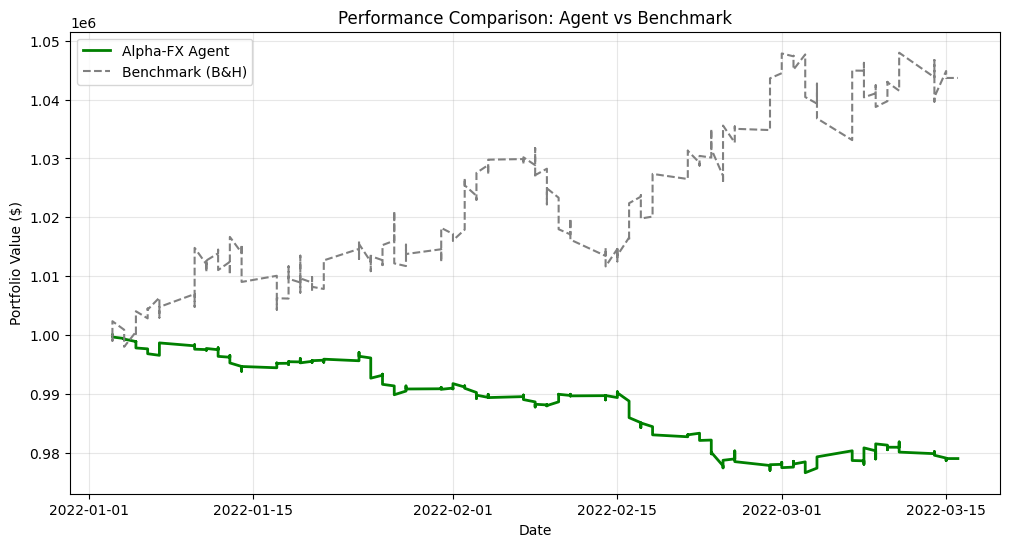

In [11]:
# Plot Equity Curve
try:
    eq_path = 'results/equity.csv'
    if os.path.exists(eq_path):
        eq_df = pd.read_csv(eq_path)
        if 'date' in eq_df.columns:
            eq_df['date'] = pd.to_datetime(eq_df['date'])
            x_axis = eq_df['date']
        else:
            x_axis = eq_df.index
            
        plt.figure(figsize=(12, 6))
        plt.plot(x_axis, eq_df['agent'], label='Alpha-FX Agent', color='green', linewidth=2)
        plt.plot(x_axis, eq_df['baseline'], label='Benchmark (B&H)', color='gray', linestyle='--')
        
        plt.title("Performance Comparison: Agent vs Benchmark")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value ($)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"No equity data found at {eq_path}. Run benchmark first.")
except Exception as e:
    print(f"Could not plot equity curve: {e}")

## 5. Conclusion

You have successfully ran the Alpha-FX pipeline.

*   **Next Steps**: 
    *   Try increasing `TOTAL_TIMESTEPS` to `100000` to see if the agent learns a better policy.
    *   Add more tickers (e.g., `'AUDUSD=X'`) in the DataOps section.